In [ ]:
import arcpy
from pathlib import Path

from IndoorsUtilsModule import listTables
from arcpy import ListFeatureClasses, ListRasters

arcpy.env.workspace = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\NooksackFishHabitatModeling\Inputs.gdb\SubstrateAndCover"
isf_survey_area = ListFeatureClasses("ISF_SurveyArea")[0]

input_gdb = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\NooksackFishHabitatModeling\Inputs.gdb"
arcpy.env.workspace = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\NooksackFishHabitatModeling\Inputs.gdb"
raster_list = ListRasters("*")


directory = Path(r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\NooksackFishHabitatModeling\2026_0311_HDR_HydroModelDepthVelocityRasters")

raster_variable = None
tide_name = None
percent_value = None
raster_number = 0
for file in directory.rglob("*.tif"):
    if file.is_file():
        subdir_name = file.parent.name
        if "Velocity" in file.name:
            raster_variable = "Velocity"
        if "Depth" in file.name:
            raster_variable = "Depth"
        if "LowTide" in subdir_name:
            tide_name = "LowTide"
        if "MHHW" in subdir_name:
            tide_name = "MHHW"
        percent_index = subdir_name.index("%")
        percent_value = subdir_name[:percent_index]
        raster_name = f"{raster_variable}{percent_value}Perc{tide_name}"
        raster_name = raster_name.replace(".","_")
        if raster_name in raster_list:
            print(f"{raster_name} already exists, skipping to next raster.")
            raster_number += 1
        else:
            print(f"Clipping {raster_name}")
            arcpy.management.Clip(
                in_raster=str(file),
                out_raster=f"{input_gdb}\\{raster_name}",
                in_template_dataset=isf_survey_area,
                nodata_value="-9999",
                clipping_geometry="ClippingGeometry",
                maintain_clipping_extent="NO_MAINTAIN_EXTENT"
            )
            raster_number += 1
            print(f"{raster_name} created, {raster_number}/32")

In [ ]:
import arcpy
from arcpy import ListTables
from arcpy.da import TableToNumPyArray
import pandas as pd

nooksack_folder = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\Substrate_Cover_MappingSupportNooksack"
outputs_gdb = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\Substrate_Cover_MappingSupportNooksack\Outputs.gdb"
arcpy.env.workspace = outputs_gdb

hsi_stats_tables_list = ListTables("*_HSI_StatsTab")
hsi_stats_dataframe_list = []
reaches_list = ["Reach 1", "Reach 2", "Reach 3", "Reach 4", "Reach 5", "Reach 6"]
percent_exceedance_flows = {
    "201": 5210,
    "209": 5210,
    "301": 4250,
    "309": 4250,
    "401": 3600,
    "409": 3600,
    "601": 2650,
    "609": 2650,
    "801": 1790,
    "809": 1790,
    "951": 1090,
    "959": 1090,
    "991": 790,
    "999": 790,
    "99991": 560,
    "99999": 560,
}
low_or_high_tide = {
    "201": "Low",
    "209": "High",
    "301": "Low",
    "309": "High",
    "401": "Low",
    "409": "High",
    "601": "Low",
    "609": "High",
    "801": "Low",
    "809": "High",
    "951": "Low",
    "959": "High",
    "991": "Low",
    "999": "High",
    "99991": "Low",
    "99999": "High",
}
fish_code_list = ["OMYs", "OMYa", "OMYj", "CHKs", "CHKj", "CHKf", "CHMf", "COHj", "COHf", "BTDVj", "CTTa", "CTTj", "CTTf"]
life_stage_dict = {
    "s": "Spawn",
    "f": "Fry",
    "j": "Juvenile",
    "a": "Adult"
}

for table in hsi_stats_tables_list:
    fish_code_flow = table[:-13]
    df = pd.DataFrame(TableToNumPyArray(table, "*"))
    df["FishCodeFlow"] = fish_code_flow
    hsi_stats_dataframe_list.append(df)
hsi_stats_table_compiled_df = pd.concat(hsi_stats_dataframe_list, axis=0, ignore_index=True)
hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["Reach"] == "Reach 1", "ReachLength_miles"] = 0.47412
hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["Reach"] == "Reach 2", "ReachLength_miles"] = 2.410013
hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["Reach"] == "Reach 3", "ReachLength_miles"] = 1.054832
hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["Reach"] == "Reach 4", "ReachLength_miles"] = 0.433739
hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["Reach"] == "Reach 5", "ReachLength_miles"] = 0.893034
hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["Reach"] == "Reach 6", "ReachLength_miles"] = 3.892461

for percent, flow in percent_exceedance_flows.items():
    hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["FishCodeFlow"].str.contains(percent), "Flow_cfs"] = flow

for fish in fish_code_list:
    hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["FishCodeFlow"].str.contains(fish), "FishSpecies"] = fish

for life_stage_code, life_stage in life_stage_dict.items():
    hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["FishSpecies"].str[-1] == life_stage_code, "LifeStage"] = life_stage

for flow, low_or_high in low_or_high_tide.items():
    hsi_stats_table_compiled_df.loc[hsi_stats_table_compiled_df["FishCodeFlow"].str.contains(flow), "LowOrHighTide"] = low_or_high

hsi_stats_table_compiled_df.to_csv(f"{nooksack_folder}\\HSI_StatsTable.csv", index=False)

In [ ]:
import arcpy
from arcpy import ListTables
from arcpy.da import TableToNumPyArray
import pandas as pd

nooksack_folder = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\Substrate_Cover_MappingSupportNooksack"
outputs_gdb = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\Substrate_Cover_MappingSupportNooksack\Outputs.gdb"
arcpy.env.workspace = outputs_gdb

suit_acres_tables_list = ListTables("*_SuitAcreTab")
suit_acres_dataframe_list = []
reaches_list = ["Reach 1", "Reach 2", "Reach 3", "Reach 4", "Reach 5", "Reach 6"]
percent_exceedance_flows = {
    "201": 5210,
    "209": 5210,
    "301": 4250,
    "309": 4250,
    "401": 3600,
    "409": 3600,
    "601": 2650,
    "609": 2650,
    "801": 1790,
    "809": 1790,
    "951": 1090,
    "959": 1090,
    "991": 790,
    "999": 790,
    "99991": 560,
    "99999": 560,
}
low_or_high_tide = {
    "201": "Low",
    "209": "High",
    "301": "Low",
    "309": "High",
    "401": "Low",
    "409": "High",
    "601": "Low",
    "609": "High",
    "801": "Low",
    "809": "High",
    "951": "Low",
    "959": "High",
    "991": "Low",
    "999": "High",
    "99991": "Low",
    "99999": "High",
}
fish_code_list = ["OMYs", "OMYa", "OMYj", "CHKs", "CHKj", "CHKf", "CHMf", "COHj", "COHf", "BTDVj", "CTTa", "CTTj", "CTTf"]
life_stage_dict = {
    "s": "Spawn",
    "f": "Fry",
    "j": "Juvenile",
    "a": "Adult"
}
for table in suit_acres_tables_list:
    fish_code_flow = table[:-12]
    df = pd.DataFrame(TableToNumPyArray(table, "*"))
    df["FishCodeFlow"] = fish_code_flow
    suit_acres_dataframe_list.append(df)
suit_acres_table_compiled_df = pd.concat(suit_acres_dataframe_list, axis=0, ignore_index=True)
suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["Reach"] == "Reach 1", "ReachLength_miles"] = 0.47412
suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["Reach"] == "Reach 2", "ReachLength_miles"] = 2.410013
suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["Reach"] == "Reach 3", "ReachLength_miles"] = 1.054832
suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["Reach"] == "Reach 4", "ReachLength_miles"] = 0.433739
suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["Reach"] == "Reach 5", "ReachLength_miles"] = 0.893034
suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["Reach"] == "Reach 6", "ReachLength_miles"] = 3.892461

for percent, flow in percent_exceedance_flows.items():
    suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["FishCodeFlow"].str.contains(percent), "Flow_cfs"] = flow

for fish in fish_code_list:
    suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["FishCodeFlow"].str.contains(fish), "FishSpecies"] = fish

for life_stage_code, life_stage in life_stage_dict.items():
    suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["FishSpecies"].str[-1] == life_stage_code, "LifeStage"] = life_stage

for flow, low_or_high in low_or_high_tide.items():
    suit_acres_table_compiled_df.loc[suit_acres_table_compiled_df["FishCodeFlow"].str.contains(flow), "LowOrHighTide"] = low_or_high

suit_acres_table_compiled_df["UsableAcresPerMile"] = suit_acres_table_compiled_df["SUM"] / suit_acres_table_compiled_df["ReachLength_miles"]

suit_acres_table_compiled_df.to_csv(f"{nooksack_folder}\\SuitAcre.csv", index=False)



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

nooksack_folder = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\Substrate_Cover_MappingSupportNooksack"
plots_folder = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\Substrate_Cover_MappingSupportNooksack\Plots_ver2"
hsi_stats_df = pd.read_csv(f"{nooksack_folder}\\HSI_StatsTable.csv")
sns.set_theme(style="white")

for (reach, low_or_high_tide, life_stage), df in hsi_stats_df.groupby(["Reach","LowOrHighTide","LifeStage"]):
    plot_df = df.copy()
    if reach != "Reach 6" and low_or_high_tide != "High":
        continue
    # if reach in ["Reach 4", "Reach 5"] and life_stage == "Spawn":
    #     plot_df = plot_df[plot_df["FishSpecies"] != "OMYs"]
    fig, ax1 = plt.subplots(figsize=(10,6))
    sns.lineplot(
        data=plot_df,
        x="Flow_cfs",
        y="MEAN",
        hue="FishSpecies",
        marker="o",
        errorbar=None,
        ax=ax1
    )
    ax1.set_ylabel("MEAN HABITAT SUITABILITY INDEX VALUE")
    ax1.set_xlabel("FLOW (CFS)")
    ax1.grid(False)
    ax1.minorticks_on()
    ax1.yaxis.set_minor_locator(AutoMinorLocator())
    ax1.legend(title="Fish Species")

    if reach == "Reach 6":
        ax1.set_title(f"{reach}, {low_or_high_tide} Tide")
    else:
        ax1.set_title(f"{reach}")

    ax1.tick_params(axis="x", which="both", bottom=True, top=False)
    ax1.tick_params(axis="y", which="both", left=True, right=False, labelleft=True)

    plt.savefig(
        f"{plots_folder}\\MEAN_HSI_PLOTS\\{reach}_{low_or_high_tide}_{life_stage}_MEAN_HSI.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

nooksack_folder = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\Substrate_Cover_MappingSupportNooksack"
plots_folder = r"C:\Users\kyashby\Documents\PROJECTS\Nooksack\Substrate_Cover_MappingSupportNooksack\Plots_ver2"
suit_acre_df = pd.read_csv(f"{nooksack_folder}\\SuitAcre.csv")
sns.set_theme(style="white")

for (reach, low_or_high_tide, life_stage), df in suit_acre_df.groupby(["Reach","LowOrHighTide","LifeStage"]):
    plot_df = df.copy()
    if reach != "Reach 6" and low_or_high_tide != "High":
        continue
    # if reach in ["Reach 4", "Reach 5"] and life_stage == "Spawn":
    #     plot_df = plot_df[plot_df["FishSpecies"] != "OMYs"]
    fig, ax1 = plt.subplots(figsize=(10,6))
    sns.lineplot(
        data=plot_df,
        x="Flow_cfs",
        y="SUM",
        hue="FishSpecies",
        marker="o",
        errorbar=None,
        ax=ax1
    )
    ax1.set_ylabel("USABLE HABITAT AREA (ACRES)")
    ax1.set_xlabel("FLOW (CFS)")
    ax1.grid(False)
    ax1.minorticks_on()
    ax1.yaxis.set_minor_locator(AutoMinorLocator())
    ax1.legend(title="Fish Species")

    ax2 = ax1.twinx()
    sns.lineplot(
        data=plot_df,
        x="Flow_cfs",
        y="UsableAcresPerMile",
        hue="FishSpecies",
        marker="o",
        errorbar=None,
        ax=ax2,
        legend=False
    )
    ax2.set_ylabel("USABLE HABITAT AREA (ACRES / MI)")
    ax2.yaxis.set_minor_locator(AutoMinorLocator())

    if reach == "Reach 6":
        ax1.set_title(f"{reach}, {low_or_high_tide} Tide")
    else:
        ax1.set_title(f"{reach}")

    ax1.tick_params(axis="x", which="both", bottom=True, top=False)
    ax1.tick_params(axis="y", which="both", left=True, right=False, labelleft=True)

    plt.savefig(
        f"{plots_folder}\\UHA_PLOTS\\{reach}_{low_or_high_tide}_{life_stage}_UHA.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()


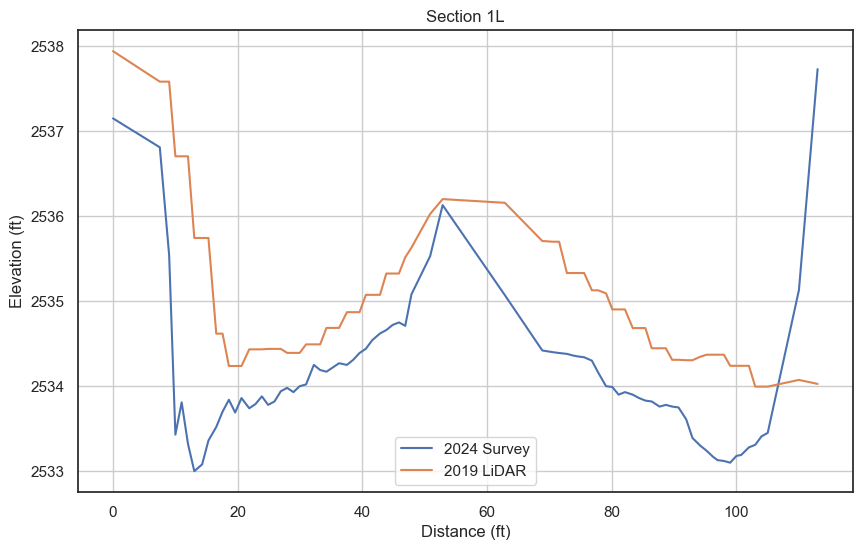

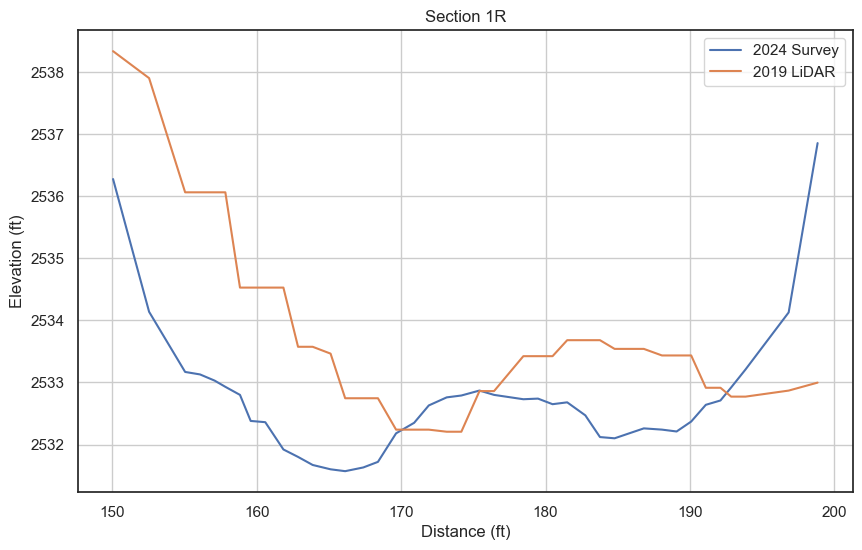

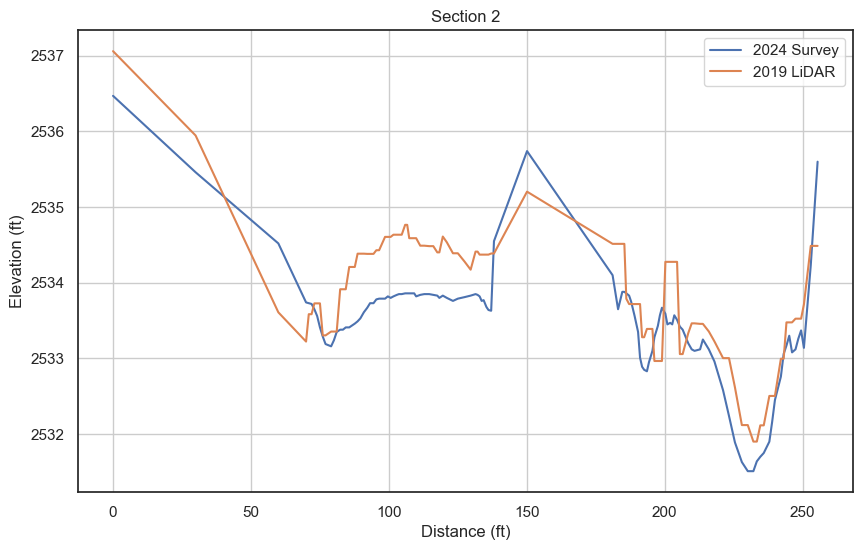

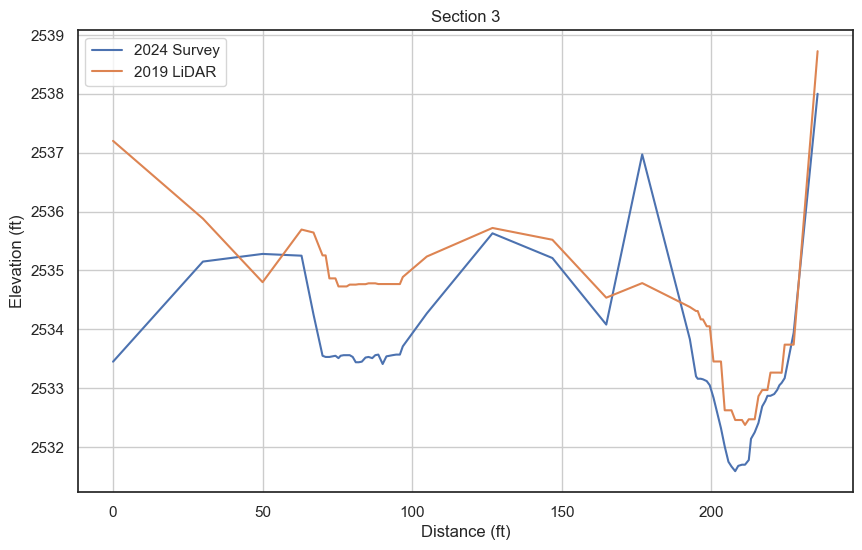

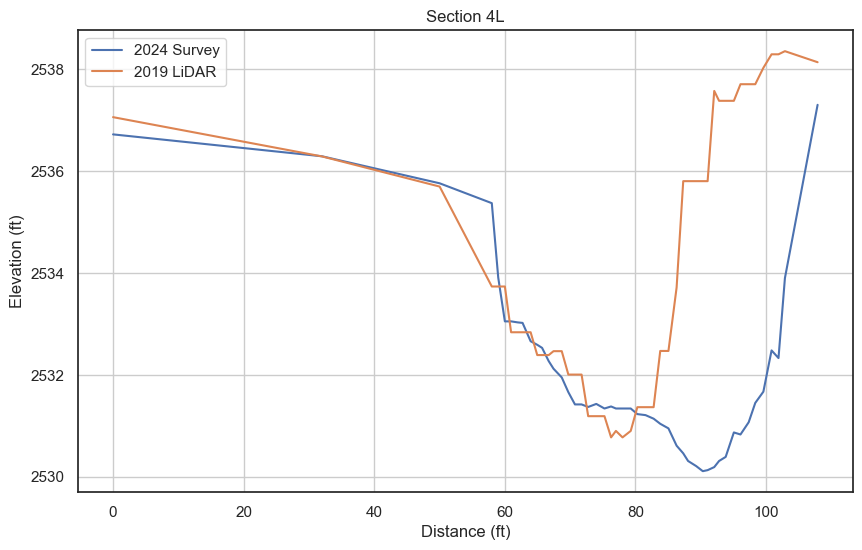

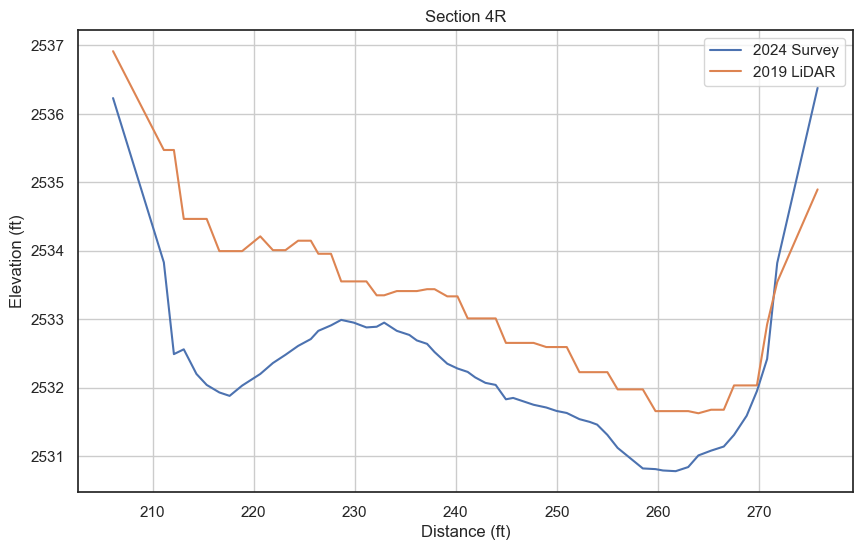

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

eagle_sewer_df = pd.read_csv(r"C:\Users\kyashby\Documents\PROJECTS\FCD10\FCD10_ArcGIS\ProjectName_000000\7.2_WIP\Data\Tables\EagleSewer_BathyPoints.csv")
plots_folder = r"C:\Users\kyashby\Documents\PROJECTS\FCD10\FCD10_ArcGIS\ProjectName_000000\7.2_WIP\Data\Plots"
sns.set_theme(style="white")
for subsection, df in eagle_sewer_df.groupby("Subsection"):
    fig, ax1 = plt.subplots(figsize=(10,6))
    sns.lineplot(
        data=df,
        x="F9",
        y="Elevation",
        label="2024 Survey",
    )
    sns.lineplot(
        data=df,
        x="F9",
        y="EagleSewer2019LiDAR",
        label="2019 LiDAR",
    )
    plt.title(f"Section {subsection}")
    plt.xlabel("Distance (ft)")
    plt.ylabel("Elevation (ft)")
    plt.legend()
    plt.grid(True)
    plt.savefig(
        f"{plots_folder}\\{subsection}_2019_2024_TerrainProfile.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()





In [1]:
from numpy import interp
xp = [0,60]
fp = [4777.31, 4777.17]
x=30
y = interp(x, xp, fp)
print(y)

4777.24
